In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns

In [2]:
# to get the different test sets
config_fp = '../experiment_configs/train_baseline_local_models.yaml'
cfg_hp_search = read_config_file(config_fp)
cfg_data = cfg_hp_search['data']
split_seed = cfg_data['split_seed']


# 1. get the data for different number of training sites


In [7]:
results_keys = ['r2','mae','mse','rmse']

results_by_num_sites_df = pd.read_csv('../results_by_num_sites_df_4splits.csv')
results_by_num_sites_df = results_by_num_sites_df.rename(columns={'split':'test_split', 'layers':'num_image_layers_used'})
results_with_subsetted_sites = results_by_num_sites_df.loc[:,results_keys + ['test_split', 'num_image_layers_used', 'num_train_sites']]
#results_with_subsetted_sites.loc[:,'model_name'] = 'FCN 4 channels (ours)'

groups = ['test_split','num_train_sites']
grouped = results_with_subsetted_sites.groupby(groups)

rows = []
results_by_num_sites = pd.DataFrame()
for name, group in grouped:
    row_df = pd.DataFrame(group.mean()).T
    row_df.loc[:,'model_name'] = f'RF ({name[1]} train sites)'
    row_df.loc[:,groups[0]] = name[0]
    row_df.loc[:,groups[1]] = name[1]
    
    results_by_num_sites= pd.concat((results_by_num_sites,row_df))
    
results_by_num_sites.sort_values(by='num_train_sites', inplace=True)

In [10]:
def plot_panel(results_by_split_df, ax, y_key='rmse'):

    sns.scatterplot(data=results_by_split_df, x='model_name',y=y_key, 
                    s=100,
                    color='lightgrey', label='each of 4 test splits',
                   ax=ax)
    sns.scatterplot(data=results_by_split_df.groupby('model_name')[[y_key]].mean(), x='model_name', y=y_key, 
                    s=100,
                    color='forestgreen', label='average across test splits',
                   ax=ax)
    
    return ax

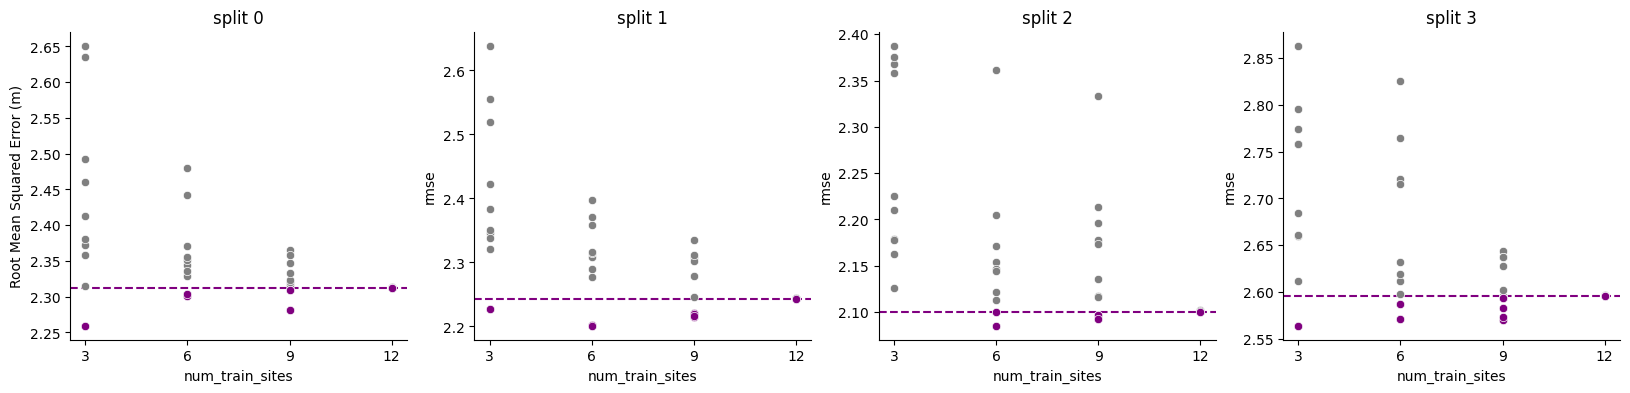

In [15]:
plot_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

fig, ax = plt.subplots(1,4,figsize=(20,4),sharey=False)

#sns.boxplot(data=results_by_layers_df, x='layers', y=plot_key, ax=ax[0])

count_num_better = pd.DataFrame()
for i in range(4):
    df_this_split = results_by_num_sites_df[results_by_num_sites_df['test_split']==i]
    
    sns.scatterplot(data=df_this_split, x='num_train_sites', y=plot_key, ax=ax[i], color='grey')
    
    ax[i].set_title(f'split {i}')
    reference = df_this_split[df_this_split['num_train_sites']==12][plot_key].min()
    sns.scatterplot(data=df_this_split[df_this_split[plot_key] <= reference], x='num_train_sites', y=plot_key, ax=ax[i], color='purple')
    
    count_better_this_split = pd.DataFrame(df_this_split[df_this_split[plot_key] < reference].groupby('num_train_sites').count()['r2'])
    count_better_this_split = count_better_this_split.rename(columns={'r2':f'split {i}'})
    
    if i == 0: count_num_better = count_better_this_split    
    else: count_num_better = pd.merge(count_num_better, count_better_this_split, on='num_train_sites', how='outer')
    
    ax[i].axhline(reference, color='purple', ls = '--', zorder=-1)
    ax[i].set_xticks([3,6,9,12])

#ax[0].set_title('# layers used')
if plot_key == 'rmse':
    ax[0].set_ylabel(metric_labels[plot_key])
sns.despine()

In [16]:
count_num_better.fillna(0)

,split 0,split 1,split 2,split 3
num_train_sites,,,,
3,1,1,0.0,1
6,2,2,2.0,2
9,2,4,2.0,4


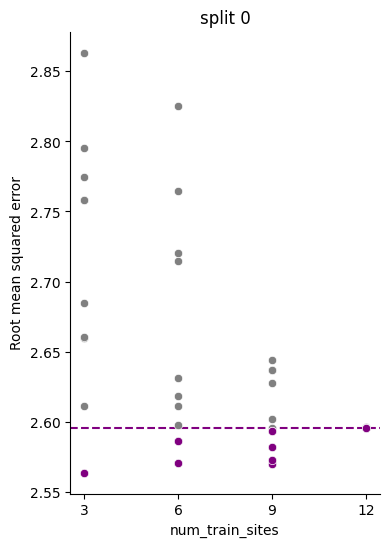

In [17]:
plot_key = 'rmse'

fig, ax = plt.subplots(1,1,figsize=(4,6),sharey=False)
ax = [ax]
#sns.boxplot(data=results_by_layers_df, x='layers', y=plot_key, ax=ax[0])

count_num_better = pd.DataFrame()
for i in range(1):
    df_this_split = results_by_num_sites_df[results_by_num_sites_df['test_split']==3]
    
    sns.scatterplot(data=df_this_split, x='num_train_sites', y=plot_key, ax=ax[i], color='grey')
    
    ax[i].set_title(f'split {i}')
    reference = df_this_split[df_this_split['num_train_sites']==12][plot_key].min()
    sns.scatterplot(data=df_this_split[df_this_split[plot_key] <= reference], x='num_train_sites', y=plot_key, ax=ax[i], color='purple')
    
    count_better_this_split = pd.DataFrame(df_this_split[df_this_split[plot_key] < reference].groupby('num_train_sites').count()['r2'])

    count_better_this_split = count_better_this_split.rename(columns={'r2':f'split {i}'})
    
    count_num_better = pd.concat((count_num_better, count_better_this_split))
    
    ax[i].axhline(reference, color='purple', ls = '--', zorder=-1)
    
    ax[i].set_xticks([3,6,9,12])

#ax[0].set_title('# layers used')

if plot_key == 'rmse':
    ax[0].set_ylabel('Root mean squared error')
sns.despine()

/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  pos

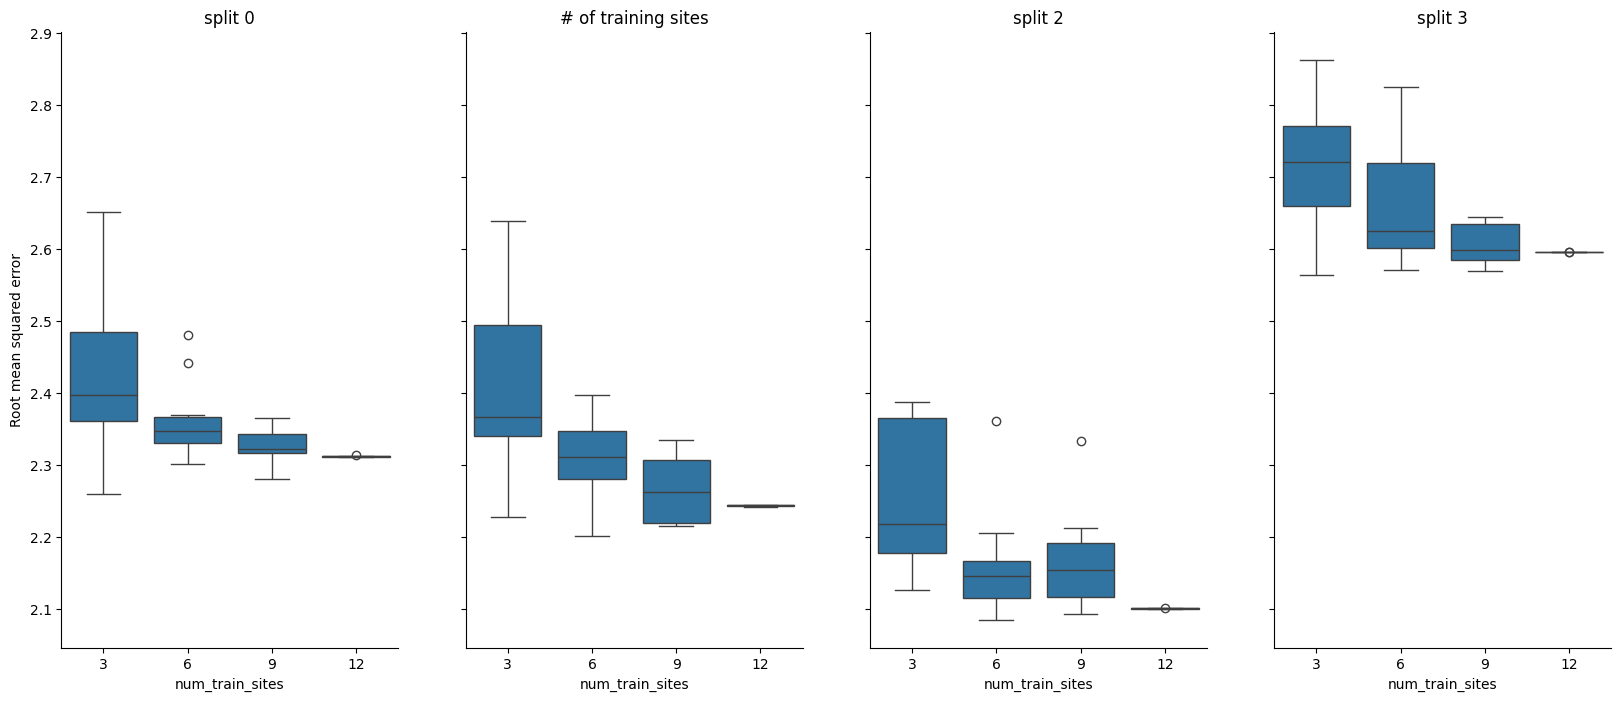

In [19]:
# same info as a boxplot
plot_key = 'rmse'

fig, ax = plt.subplots(1,4,figsize=(20,8),sharey=True)

#sns.boxplot(data=results_by_layers_df, x='layers', y=plot_key, ax=ax[0])
for i in range(4):
    sns.boxplot(data=results_by_num_sites_df[results_by_num_sites_df['test_split']==i], x='num_train_sites', y=plot_key, ax=ax[i])
    ax[i].set_title(f'split {i}')

#ax[0].set_title('# layers used')
ax[1].set_title('# of training sites')     
if plot_key == 'rmse':
    ax[0].set_ylabel('Root mean squared error')
sns.despine()